# HI Observation
- Designated code for `Undergraduate Radio Lab`, Prof. Junhan Kim
- Revised by Jiwon Jang 
- Original code was developed by TA's of the 2024/2025 SNU NaturalScience Camp, including Donghwan Hyeon, Jiwon Jang, Wooseok Kang, Chanjin Lee, Wonhyeong Lee.  

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Basic SDR modules
from radio import set_root_dir, get_data_dir, get_log_dir
from radio.sdr import Exposure, expose_sdr
from radio.constants import N_FFT
from radio.io import load_data, load_spectra_from_list, load_source_header
from radio.utils import LSR_correction, plot_psd

# set the root directory location
set_root_dir(Path.cwd()) 

WindowsPath('C:/Programing/Astronomy/Internship_ugrlab')

In [3]:
f0 = 1420.40575  # rest frame frequency of HI [MHz]
fs = 3.0 # sampling frequency [MHz]

In [16]:
plt.rcParams['axes.unicode_minus'] =False
plt.rcParams['mathtext.fontset']='stix'
plt.rcParams['font.size']=18
plt.rcParams['legend.frameon']=False

# Check the Connection

In [ ]:
from rtlsdr import RtlSdr
try:
    sdr = RtlSdr()
    print("SDR Device found!")
    sdr.close()
except:
    print("SDR Device not found. Please check your drivers.")

SDR Device found!


[Ch 1] Bias-tee disabled (failed=0)


# Observation

In [ ]:
gnd = Exposure(idx=1, n_obs = 60, exposure_type = 'gnd', center_freq = f0*1e6)
gnd.run()

Exposure = gnd
------------------------------------------------------------
Data will be saved at [2026-04-29T08:13:40]


Iteration:   0%|          | 0/60 [00:00<?, ?it/s]

Exposure finished, 60 frame accumulated (t_exp = 5.24s)
------------------------------------------------------------


In [53]:
sky = Exposure(idx=1, n_obs = 60, exposure_type = 'sky', center_freq = f0*1e6)
sky.run()

Exposure = sky
------------------------------------------------------------
Altitude [deg] = 87.8
Azimuthal angle [deg] = 153
87.8 153.0 <class 'float'>
(ra, dec) = 06h31m50.92781299s +34d25m13.52473487s
97.96219922077441 34.4204235374641 2026-04-28T07:34:07
(l, b) = 179d51m41.19271905s 11d14m56.73529622s
179.86144242195707 11.24909313783866 2026-04-28T07:34:07
Data will be saved at [2026-04-28T07:34:07] with l=180, b=11


Iteration:   0%|          | 0/3000 [00:00<?, ?it/s]

Exposure finished, 3000 frame accumulated (t_exp = 262.14s)
------------------------------------------------------------


# Load Data

### Load Data

In [18]:
# [Caution!!]: Cleaning the directory
log_path.unlink()
data_flist = list(get_data_dir().glob('*.csv'))
for fpath in data_flist:
    fpath.unlink()

In [6]:
log_path = list(get_log_dir().glob('log_*.csv'))[2]
log = load_data(log_path)
gnd_spectra, gnd_missing = load_spectra_from_list(log, exposure_type = 'gnd')
gnd_flist = list(gnd_spectra.keys())
log

Data directory = C:\Programing\Astronomy\Internship_ugrlab\data
------ loaded -------
2026-04-28T06-09-37_26.2s_gnd.csv
2026-04-28T06-16-37_26.2s_gnd.csv
2026-04-28T06-38-42_26.2s_gnd.csv



UT,type,channel,obs_lat [deg],obs_lon [deg],alt [deg],az [deg],l [deg],b [deg],fcen [MHz],fsample [MHz],ADC gain,n_obs,t_exp [s],filename
str19,str3,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,str40
2026-04-28T06:09:37,gnd,1,36.36944444,127.36416667,nan,nan,nan,nan,1420.406,3.0,50.0,300,26.2144,2026-04-28T06-09-37_26.2s_gnd.csv
2026-04-28T06:10:53,sky,1,36.36944444,127.36416667,89.5,180.0,169.31,-3.46,1420.406,3.0,50.0,300,26.2144,2026-04-28T06-10-53_169_-3_26.2s_sky.csv
2026-04-28T06:16:37,gnd,1,36.36944444,127.36416667,nan,nan,nan,nan,1420.406,3.0,50.0,300,26.2144,2026-04-28T06-16-37_26.2s_gnd.csv
2026-04-28T06:17:25,sky,1,36.36944444,127.36416667,89.6,180.0,170.02,-2.34,1420.406,3.0,50.0,300,26.2144,2026-04-28T06-17-25_170_-2_26.2s_sky.csv
2026-04-28T06:22:29,sky,1,36.36944444,127.36416667,36.1,140.0,224.05,2.92,1420.406,3.0,50.0,300,26.2144,2026-04-28T06-22-29_224_3_26.2s_sky.csv
2026-04-28T06:26:17,sky,1,36.36944444,127.36416667,36.1,140.0,224.49,3.75,1420.406,3.0,50.0,3000,262.144,2026-04-28T06-26-17_224_4_262.1s_sky.csv
2026-04-28T06:38:42,gnd,1,36.36944444,127.36416667,nan,nan,nan,nan,1420.406,3.0,50.0,300,26.2144,2026-04-28T06-38-42_26.2s_gnd.csv
2026-04-28T06:39:38,sky,1,36.36944444,127.36416667,36.1,140.0,226.07,6.67,1420.406,3.0,50.0,300,26.2144,2026-04-28T06-39-38_226_7_26.2s_sky.csv
2026-04-28T06:45:38,sky,1,36.36944444,127.36416667,44.5,155.0,218.04,-3.17,1420.406,3.0,50.0,300,26.2144,2026-04-28T06-45-38_218_-3_26.2s_sky.csv


In [7]:
# load ground spectra
gnd_spectra, gnd_missing = load_spectra_from_list(log, exposure_type = 'gnd')
gnd_flist = list(gnd_spectra.keys())
gnd_fname = gnd_flist[-1]
gnd_hdr = load_source_header(log, gnd_fname)

# load sky (source) spectra
src_spectra, src_missing = load_spectra_from_list(log, exposure_type = 'sky',alt=87.8, az=153)# alt = 36.1, az = 140)
src_flist = list(src_spectra.keys())
src_fname = src_flist[-1]
src_hdr = load_source_header(log, src_fname)

freq =  np.array(src_spectra[src_fname]['frequency'])
P_src =  np.array(src_spectra[src_fname]['power'])
P_amb =  np.array(gnd_spectra[gnd_fname]['power'])

Data directory = C:\Programing\Astronomy\Internship_ugrlab\data
------ loaded -------
2026-04-28T06-09-37_26.2s_gnd.csv
2026-04-28T06-16-37_26.2s_gnd.csv
2026-04-28T06-38-42_26.2s_gnd.csv

Data directory = C:\Programing\Astronomy\Internship_ugrlab\data
------ loaded -------
2026-04-28T06-59-43_177_5_26.2s_sky.csv



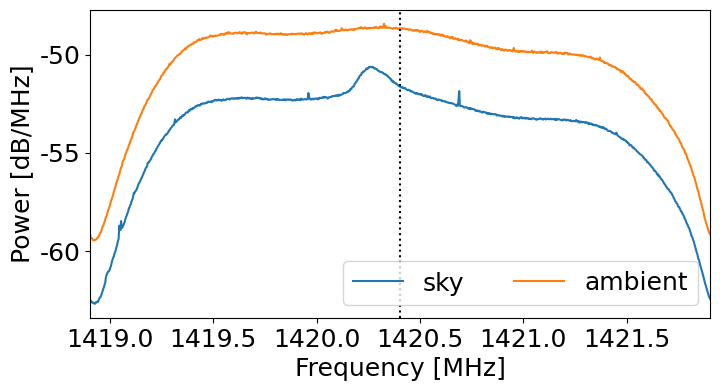

In [8]:
ax = plot_psd(freq, P_src, ax=None, label='sky')
ax = plot_psd(freq, P_amb, ax=ax, label='ambient')
ax.axvline(f0,ls=':',color='k')
ax.legend(frameon=True, ncols=2)

# Data Reduction

## 1. Flux Calibration

We start by writing
$$
P_{\mathrm{src}} = G (T_{\mathrm{src}} + T_{\mathrm{sys}}) \\
$$
$$
P_{\mathrm{amb}} = G (T_{\mathrm{amb}} + T_{\mathrm{sys}}) \\
$$
$$
P_{\mathrm{sky}} = G (T_{\rm sky} + T_{\mathrm{sys}}) \\
$$
(spectral dependence simplified).

In our case, we couldn't take $P_{sky}$!


We use 
$$
Y \equiv \dfrac{P_{\rm hot}}{P_{\rm cold}} = \dfrac{P_{\mathrm{amb}}}{P_{\mathrm{sky}}} \simeq \dfrac{P_{\mathrm{amb}}}{P_{\mathrm{src, off-line}}} \\
$$
$$
P_{\mathrm{sky}} \simeq \dfrac{P_{\mathrm{amb}}}{Y} \\
$$

Solving for $T_{sys}$,

$$
T_{\mathrm{sys}} = \dfrac{T_{\rm amb}-YT_{\rm sky}}{Y-1} \simeq \dfrac{T_{amb}}{Y-1}
$$
<!-- $$
T_{\mathrm{sys}} = \frac{T_{H} - Y\times T_{L}}{Y-1}
$$ -->


, which leads to

$$
T_{\mathrm{src}} \simeq \dfrac{P_{\mathrm{src}} - P_{\mathrm{sky}}}{P_{sky}} T_{sys} = \dfrac{P_{\mathrm{src}} - P_{\mathrm{sky}}}{P_{amb} - P_{sky}} T_{amb} \\
$$

<!-- T_{sky} -->

In [9]:
T_sky = 10  # K
T_amb = 300  # 273.15 K + 30 K

# Y-factor
Y = np.median(P_amb / P_src)
P_sky = P_amb / Y

# antenna temperature
T_src = (P_src - P_sky) / (P_amb - P_sky) * T_amb

### Plot

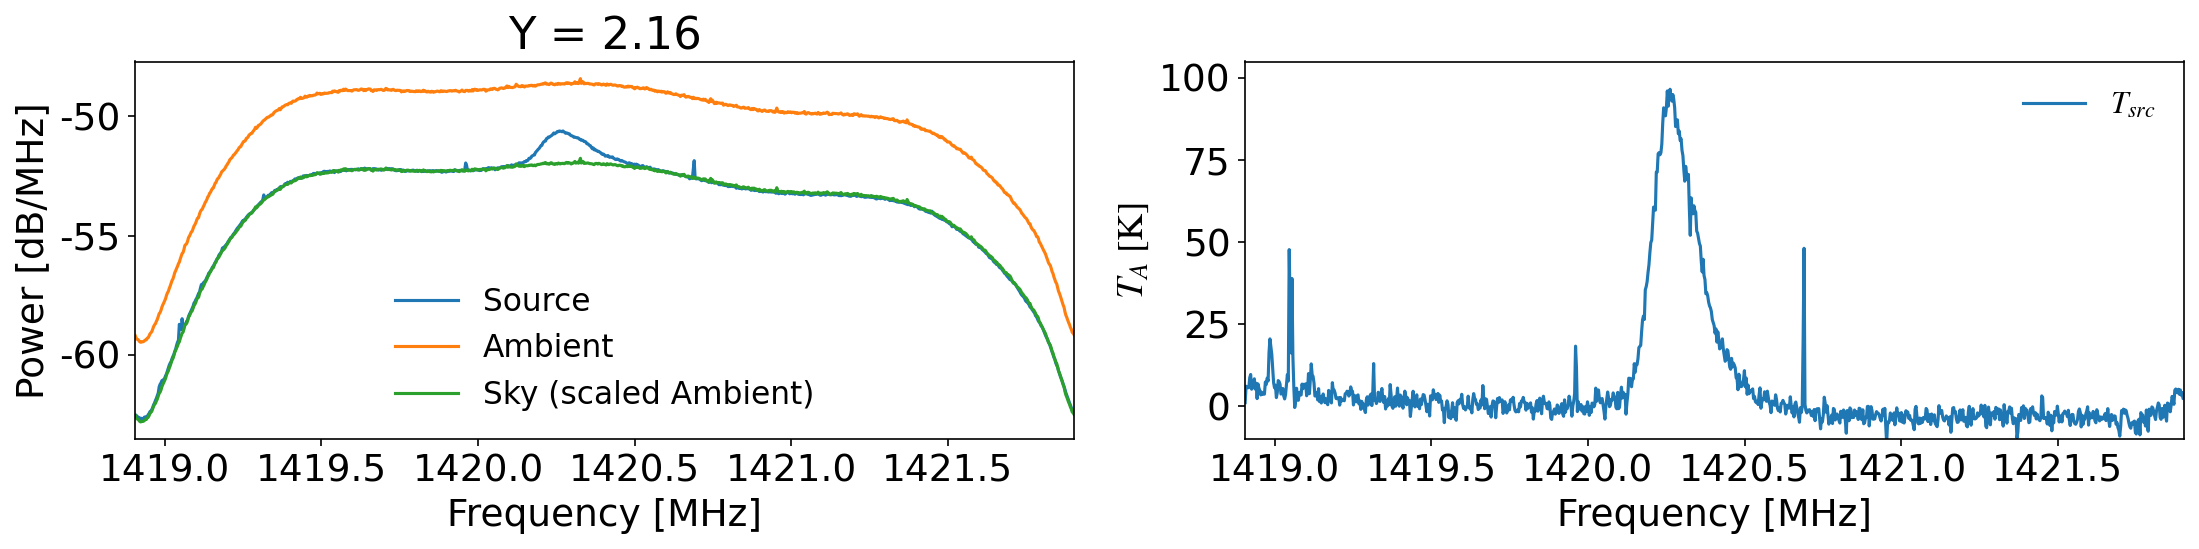

In [14]:
fig, ax = plt.subplots(1,2,figsize = (15,4), dpi = 150)
# Fig 1: Y-factor calculation
ax[0].set_title(f"Y = {Y:.2f}")
ax[0].plot(freq, 10 * np.log10(P_src), label="Source")
ax[0].plot(freq, 10 * np.log10(P_amb), label="Ambient")
ax[0].plot(freq, 10 * np.log10(P_sky), label="Sky (scaled Ambient)")
ax[0].set_ylabel("Power [dB/MHz]")
ax[0].set_xlabel("Frequency [MHz]")
ax[0].set_xlim(freq[0], freq[-1])
ax[0].legend(fontsize = 15)

# Fig 2: Antenna Temperature
ax[1].plot(freq, T_src, label=r"$T_{src}$")
ax[1].set_xlim(freq[0], freq[-1])
ax[1].set_ylim(-10,105)
ax[1].set_ylabel(r"$T_A\rm\;[K]$")
ax[1].set_xlabel("Frequency [MHz]")
ax[1].legend(fontsize = 15)
plt.tight_layout()
plt.show()

## 2. Frequency $\rightarrow$ LSR velocity

### Frequency to Velocity

We convert the frequency to line-of-sight velocity to see the kinematics of the HI gas clouds.

### LSR correction
- Correcting the orbitatl motion of the Earth around the sun.
- The solar system also moves at 20.0 km/s toward l=56°, b=23° with respect to the LSR. Decomposed, it corresponds to [U, V, W] = [10, 5, 7]

In [ ]:
# convert frequency to radial velocity
V_r = - c * (freq - f0) / freq

# LSR velocity
helio_corr, peculiar_corr = LSR_correction(l = src_hdr.l, b = src_hdr.b , obstime = src_hdr.obstime)
V_corr = helio_corr + peculiar_corr
print(f"Heliocentric correction (obs → helio): {helio_corr:.2f} km/s")
print(f"Solar-motion correction (helio → LSR): {peculiar_corr:.2f} km/s")
print(f"Total LSR correction (obs → LSR): {V_corr:.2f} km/s")
V_LSR = V_r + V_corr

Heliocentric correction (obs → helio): -16.74 km/s
Solar-motion correction (helio → LSR): 5.80 km/s
Total LSR correction (obs → LSR): -10.93 km/s


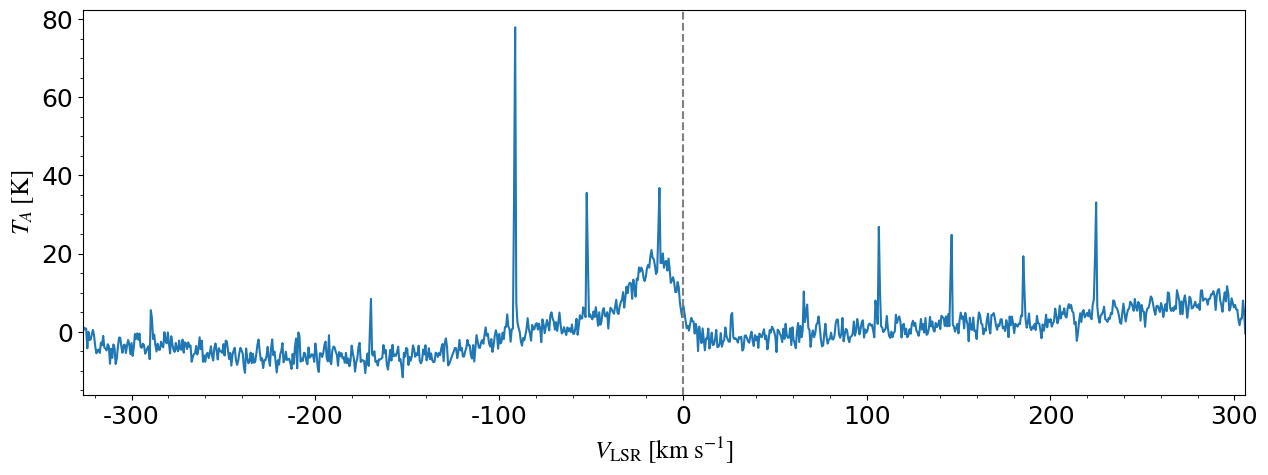

In [62]:
plt.figure(figsize=(15, 5))
plt.plot(V_LSR, T_src, color="C0")
plt.axvline(0, ls="dashed", color="gray")
plt.xlim(np.min(V_LSR), np.max(V_LSR))
plt.xlabel(r"$ V_{\rm LSR}\rm\;[km\ s^{-1}]$")
plt.ylabel(r"$T_A\rm\;[K]$")
plt.minorticks_on()
plt.show()